In [21]:
import os, sys, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

sys.path.insert(0, "/home/silvija/saiteja")
OUT_DIR  = "/data/silvija/diffusion_results"
zr_path  = os.path.join(OUT_DIR, "zr_features.npy")          
xml_path = os.path.join(OUT_DIR, "xml_features_proj.npy")  

device: cuda


In [22]:
from clip_model import SceneClipModelPad

CLIP_CKPT = "/home/silvija/saiteja/lightning_logs/version_7/checkpoints/epoch=299-step=2400.ckpt"  
clip = SceneClipModelPad(projected_emb_dim=128, num_fc_layers=2).to(device)

ckpt = torch.load(CLIP_CKPT, map_location="cpu")
state = ckpt["state_dict"] if (isinstance(ckpt, dict) and "state_dict" in ckpt) else ckpt
missing, unexpected = clip.load_state_dict(state, strict=True)
print("Missing:", len(missing))
print("Unexpected:", len(unexpected))

clip.eval()
for p in clip.parameters():
    p.requires_grad_(False)
print("CLIP Frozen")
print("zr_projection:\n", clip.zr_projection)

Missing: 0
Unexpected: 0
CLIP Frozen
zr_projection:
 ProjectionHead(
  (layers): ModuleList(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=128, bias=True)
  )
  (projection): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=128, bias=True)
  )
)


In [23]:
class ZFeatDataset(Dataset):
    def __init__(self, zr_path, xml_proj_path):
        zr   = np.ascontiguousarray(np.load(zr_path), dtype=np.float32)
        xmlp = np.ascontiguousarray(np.load(xml_proj_path), dtype=np.float32)
        assert zr.shape[0] == xmlp.shape[0], (zr.shape, xmlp.shape)
        assert zr.shape[1] == 128, zr.shape
        assert xmlp.shape[1] == 64,  xmlp.shape
        self.zr   = torch.from_numpy(zr)
        self.xmlp = torch.from_numpy(xmlp)

    def __len__(self):
        return self.zr.shape[0]

    def __getitem__(self, idx):
        return self.xmlp[idx], self.zr[idx]

ds = ZFeatDataset(zr_path, xml_path)
print("Dataset size:", len(ds))


Dataset size: 10000


In [24]:
def linear_beta_schedule(T, beta_start=1e-4, beta_end=0.02, device="cpu"):
    betas = torch.linspace(beta_start, beta_end, T, device=device)
    alphas = 1.0 - betas
    abar = torch.cumprod(alphas, dim=0)
    return betas, alphas, abar

def extract(a, t, x_shape):
    out = a.gather(0, t)  # [B]
    while len(out.shape) < len(x_shape):
        out = out.unsqueeze(-1)
    return out

class ConditionalVectorDDPM(nn.Module):
    def __init__(self, denoiser: nn.Module, T: int = 300):
        super().__init__()
        self.denoiser = denoiser
        self.T = T
        self._schedule_set = False

    def set_schedule(self, device):
        betas, alphas, abar = linear_beta_schedule(self.T, device=device)
        self.register_buffer("betas", betas)
        self.register_buffer("alphas", alphas)
        self.register_buffer("abar", abar)
        self.register_buffer("sqrt_abar", torch.sqrt(abar))
        self.register_buffer("sqrt_1m_abar", torch.sqrt(1.0 - abar))
        self.register_buffer("sqrt_recip_abar", torch.sqrt(1.0 / abar))
        self.register_buffer("sqrt_recipm1_abar", torch.sqrt(1.0 / abar - 1.0))
        self._schedule_set = True

    # q(x_t | x0) = sqrt(abar)*x0 + sqrt(1-abar)*noise
    def q_sample(self, x0, t, noise):
        return (
            extract(self.sqrt_abar, t, x0.shape) * x0
            + extract(self.sqrt_1m_abar, t, x0.shape) * noise
        )

    # x0_hat = (x_t - sqrt(1-abar)*eps) / sqrt(abar)
    def predict_x0_from_eps(self, x_t, t, eps):
        return (
            extract(self.sqrt_recip_abar, t, x_t.shape) * x_t
            - extract(self.sqrt_recipm1_abar, t, x_t.shape) * eps
        )

    def forward_train(self, x0, context):
        B = x0.shape[0]
        t = torch.randint(0, self.T, (B,), device=x0.device, dtype=torch.long)
        noise = torch.randn_like(x0)
        x_t = self.q_sample(x0, t, noise)
        pred_noise = self.denoiser(x_t, t, context)
        x0_hat = self.predict_x0_from_eps(x_t, t, pred_noise)
        return pred_noise, noise, x_t, t, x0_hat

    @torch.no_grad()
    def p_sample(self, x_t, t, context):
        eps = self.denoiser(x_t, t, context)
        x0_hat = self.predict_x0_from_eps(x_t, t, eps)

        beta_t = extract(self.betas, t, x_t.shape)
        alpha_t = extract(self.alphas, t, x_t.shape)
        abar_t = extract(self.abar, t, x_t.shape)
        abar_prev = extract(self.abar, (t - 1).clamp(min=0), x_t.shape)

        mean = (
            (torch.sqrt(abar_prev) * beta_t / (1.0 - abar_t)) * x0_hat
            + (torch.sqrt(alpha_t) * (1.0 - abar_prev) / (1.0 - abar_t)) * x_t
        )

        if (t == 0).all():
            return x0_hat

        noise = torch.randn_like(x_t)
        var = beta_t * (1.0 - abar_prev) / (1.0 - abar_t)
        return mean + torch.sqrt(var.clamp(min=1e-20)) * noise

    @torch.no_grad()
    def sample(self, context, shape):
        x = torch.randn(shape, device=context.device)
        for ti in reversed(range(self.T)):
            t = torch.full((shape[0],), ti, device=context.device, dtype=torch.long)
            x = self.p_sample(x, t, context)
        return x


In [25]:
class ResBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv1 = nn.Conv1d(ch, ch, 3, padding=1)
        self.conv2 = nn.Conv1d(ch, ch, 3, padding=1)
        self.norm1 = nn.GroupNorm(8, ch)
        self.norm2 = nn.GroupNorm(8, ch)

    def forward(self, x):
        h = self.conv1(x)
        h = self.norm1(h)
        h = F.silu(h)
        h = self.conv2(h)
        h = self.norm2(h)
        return F.silu(x + h)

class CondDenoiserConv(nn.Module):
    def __init__(self, x_dim=128, ctx_dim=128, ch=64, emb_dim=256, T=300):
        super().__init__()
        self.T = T

        self.in_conv = nn.Conv1d(1, ch, 3, padding=1)

        self.time_embed = nn.Sequential(
            nn.Linear(1, emb_dim),
            nn.SiLU(),
            nn.Linear(emb_dim, emb_dim),
        )
        self.ctx_embed = nn.Sequential(
            nn.Linear(ctx_dim, emb_dim),
            nn.SiLU(),
            nn.Linear(emb_dim, emb_dim),
        )

        self.to_film = nn.Linear(emb_dim, 2 * ch)

        self.block1 = ResBlock(ch)
        self.block2 = ResBlock(ch)
        self.block3 = ResBlock(ch)

        self.out_conv = nn.Conv1d(ch, 1, 3, padding=1)

    def forward(self, x_t, t, context):
        # x_t: [B,128], context: [B,128]
        x = x_t.unsqueeze(1)  # [B,1,128]

        t_norm = (t.float() / (self.T - 1)).unsqueeze(-1)  # [B,1]
        emb = self.time_embed(t_norm) + self.ctx_embed(context)  # [B,emb_dim]

        gamma, beta = self.to_film(emb).chunk(2, dim=-1)  # [B,ch], [B,ch]
        gamma = gamma.unsqueeze(-1)  # [B,ch,1]
        beta  = beta.unsqueeze(-1)   # [B,ch,1]

        h = self.in_conv(x)                # [B,ch,128]
        h = h * (1 + gamma) + beta         # FiLM

        h = self.block1(h)
        h = self.block2(h)
        h = self.block3(h)

        out = self.out_conv(h)             # [B,1,128]
        return out.squeeze(1)              # [B,128]



In [26]:
def cosine_alignment_loss(a, b):
    a = F.normalize(a, dim=-1)
    b = F.normalize(b, dim=-1)
    return (1.0 - F.cosine_similarity(a, b, dim=-1)).mean()

In [27]:
T = 300
CTX_DIM = 128

denoiser = CondDenoiserConv(x_dim=128, ctx_dim=CTX_DIM, T=T).to(device)
diffusion = ConditionalVectorDDPM(denoiser, T=T).to(device)
diffusion.set_schedule(device)

LAM_MSE = 0.1
LAM_COS = 0.1
print("LAM_MSE:", LAM_MSE, "LAM_COS:", LAM_COS)

opt = torch.optim.AdamW(denoiser.parameters(), lr=2e-4, weight_decay=1e-4)

# Split + loaders
g = torch.Generator().manual_seed(42)
n_total = len(ds)
n_val = int(0.1 * n_total)
n_train = n_total - n_val
train_ds, val_ds = random_split(ds, [n_train, n_val], generator=g)

dl_train = DataLoader(train_ds, batch_size=256, shuffle=True,  drop_last=True,  num_workers=4, pin_memory=True)
dl_val   = DataLoader(val_ds,   batch_size=256, shuffle=False, drop_last=False, num_workers=4, pin_memory=True)

print("Train size:", len(train_ds), "Val size:", len(val_ds))


epochs = 300
CKPT_DIR = os.path.join(OUT_DIR, "diffusion_ckpts")
os.makedirs(CKPT_DIR, exist_ok=True)

train_total_losses, val_total_losses = [], []
train_mse_losses, train_cos_losses = [], []
val_mse_losses, val_cos_losses = [], []

start_train_time = time.time()
step = 0

for ep in range(1, epochs + 1):
    denoiser.train()

    tr_total_sum = tr_mse_sum = tr_cos_sum = 0.0
    tr_n = 0

    # ---- TRAIN ----
    for xml_proj, zr_feat in dl_train:
        xml_proj = xml_proj.to(device, non_blocking=True)  # [B,64]
        zr_feat  = zr_feat.to(device, non_blocking=True)   # [B,128]

        # Context from CLIP 
        with torch.no_grad():
            xml_ctx = clip.xml_projection(clip.xml_encoder(xml_proj))  # [B,128]
            xml_ctx = F.normalize(xml_ctx, dim=-1)

        pred_noise, true_noise, x_t, t, x0_hat = diffusion.forward_train(zr_feat, xml_ctx)

        loss_mse = F.mse_loss(pred_noise, true_noise)

        zr_enc_hat = clip.zr_encoder(x0_hat)          # [B,128]
        zr_enc_hat = F.normalize(zr_enc_hat, dim=-1)

        loss_cos = cosine_alignment_loss(zr_enc_hat, xml_ctx)
        loss = LAM_MSE * loss_mse + LAM_COS * loss_cos

        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(denoiser.parameters(), 1.0)
        opt.step()

        bs = zr_feat.shape[0]
        tr_total_sum += loss.item() * bs
        tr_mse_sum   += loss_mse.item() * bs
        tr_cos_sum   += loss_cos.item() * bs
        tr_n += bs

        if step % 50 == 0:
            with torch.no_grad():
                cos = F.cosine_similarity(zr_enc_hat, xml_ctx, dim=-1).mean().item()
            print(f"ep {ep} step {step} | mse {loss_mse.item():.4f} | cosLoss {loss_cos.item():.4f} | cos {cos:.4f} | total {loss.item():.4f}")

        step += 1

    tr_total = tr_total_sum / max(1, tr_n)
    tr_mse   = tr_mse_sum   / max(1, tr_n)
    tr_cos   = tr_cos_sum   / max(1, tr_n)

    train_total_losses.append(tr_total)
    train_mse_losses.append(tr_mse)
    train_cos_losses.append(tr_cos)

    # ---- VAL ----
    denoiser.eval()
    va_total_sum = va_mse_sum = va_cos_sum = 0.0
    va_n = 0

    with torch.no_grad():
        for xml_proj, zr_feat in dl_val:
            xml_proj = xml_proj.to(device, non_blocking=True)
            zr_feat  = zr_feat.to(device, non_blocking=True)

            xml_ctx = clip.xml_projection(clip.xml_encoder(xml_proj))
            xml_ctx = F.normalize(xml_ctx, dim=-1)

            pred_noise, true_noise, x_t, t, x0_hat = diffusion.forward_train(zr_feat, xml_ctx)

            loss_mse = F.mse_loss(pred_noise, true_noise)

            zr_enc_hat = F.normalize(clip.zr_encoder(x0_hat), dim=-1)
            loss_cos = cosine_alignment_loss(zr_enc_hat, xml_ctx)

            loss = LAM_MSE * loss_mse + LAM_COS * loss_cos

            bs = zr_feat.shape[0]
            va_total_sum += loss.item() * bs
            va_mse_sum   += loss_mse.item() * bs
            va_cos_sum   += loss_cos.item() * bs
            va_n += bs

    va_total = va_total_sum / max(1, va_n)
    va_mse   = va_mse_sum   / max(1, va_n)
    va_cos   = va_cos_sum   / max(1, va_n)

    val_total_losses.append(va_total)
    val_mse_losses.append(va_mse)
    val_cos_losses.append(va_cos)

    print(f"[EP {ep:03d}] train_total={tr_total:.6f} | val_total={va_total:.6f} | train_cos={tr_cos:.6f} | val_cos={va_cos:.6f}")

    ckpt_path = os.path.join(CKPT_DIR, f"denoiser_ep{ep}.pt")
    torch.save({"denoiser": denoiser.state_dict(), "T": T, "LAM_MSE": LAM_MSE, "LAM_COS": LAM_COS}, ckpt_path)

train_elapsed = time.time() - start_train_time
print(f"\nTRAINED FOR: {epochs} epochs")
print(f"TRAINING TIME: {train_elapsed/60:.2f} minutes ({train_elapsed:.1f} seconds)")
print("Last ckpt dir:", CKPT_DIR)


LAM_MSE: 0.1 LAM_COS: 0.1
Train size: 9000 Val size: 1000
ep 1 step 0 | mse 2.0859 | cosLoss 1.0051 | cos -0.0051 | total 0.3091
[EP 001] train_total=0.122670 | val_total=0.104979 | train_cos=0.986303 | val_cos=0.963557
ep 2 step 50 | mse 0.0750 | cosLoss 0.9522 | cos 0.0478 | total 0.1027
[EP 002] train_total=0.103881 | val_total=0.102651 | train_cos=0.950409 | val_cos=0.942293
ep 3 step 100 | mse 0.1061 | cosLoss 0.9295 | cos 0.0705 | total 0.1036
[EP 003] train_total=0.101896 | val_total=0.100425 | train_cos=0.933094 | val_cos=0.926426
[EP 004] train_total=0.099972 | val_total=0.099158 | train_cos=0.921341 | val_cos=0.912245
ep 5 step 150 | mse 0.0706 | cosLoss 0.9058 | cos 0.0942 | total 0.0976
[EP 005] train_total=0.098371 | val_total=0.098083 | train_cos=0.907734 | val_cos=0.904113
ep 6 step 200 | mse 0.0656 | cosLoss 0.9010 | cos 0.0990 | total 0.0967
[EP 006] train_total=0.097941 | val_total=0.095527 | train_cos=0.903056 | val_cos=0.895136
[EP 007] train_total=0.098600 | val_to

In [28]:
dl_eval = DataLoader(ds, batch_size=256, shuffle=False, num_workers=4, pin_memory=True)

gen_list = []
ctx_list = []

start_time = time.time()
denoiser.eval()
with torch.no_grad():
    for xml_proj, _zr_feat in dl_eval:
        xml_proj = xml_proj.to(device, non_blocking=True)

        xml_ctx = clip.xml_projection(clip.xml_encoder(xml_proj))
        xml_ctx = F.normalize(xml_ctx, dim=-1)  # [B,128]

        x_gen = diffusion.sample(context=xml_ctx, shape=(xml_ctx.shape[0], 128))

        gen_list.append(x_gen.cpu())
        ctx_list.append(xml_ctx.cpu())

elapsed_time = time.time() - start_time
print(f"Sampling elapsed time: {elapsed_time:.3f} seconds")

zr_gen = torch.cat(gen_list, dim=0).numpy().astype(np.float32)
xml_ctx_used = torch.cat(ctx_list, dim=0).numpy().astype(np.float32)

zr_gen_path = os.path.join(OUT_DIR, "zr_features_gen.npy")
xml_ctx_path = os.path.join(OUT_DIR, "xml_ctx_used.npy")

np.save(zr_gen_path, zr_gen)
np.save(xml_ctx_path, xml_ctx_used)

print("Saved generated:", zr_gen_path)
print("Saved ctx used :", xml_ctx_path)
print("zr_gen:", zr_gen.shape, "xml_ctx_used:", xml_ctx_used.shape)


Sampling elapsed time: 21.831 seconds
Saved generated: /data/silvija/diffusion_results/zr_features_gen.npy
Saved ctx used : /data/silvija/diffusion_results/xml_ctx_used.npy
zr_gen: (10000, 128) xml_ctx_used: (10000, 128)


In [29]:

zr_gen_t = torch.from_numpy(zr_gen).to(device)
xmlp_t   = torch.from_numpy(xml_ctx_used).to(device)

with torch.no_grad():
    zr_enc = F.normalize(clip.zr_encoder(zr_gen_t), dim=-1)  # [N,128]
    xmlp_t = F.normalize(xmlp_t, dim=-1)                    # [N,128]
    cos_diag = F.cosine_similarity(zr_enc, xmlp_t, dim=-1)

print("diag cosine mean:", cos_diag.mean().item())
print("diag cosine std :", cos_diag.std(unbiased=False).item())
print("diag cosine min/max:", cos_diag.min().item(), cos_diag.max().item())

diag cosine mean: 0.06204404681921005
diag cosine std : 0.007952597923576832
diag cosine min/max: 0.022848740220069885 0.08399064093828201


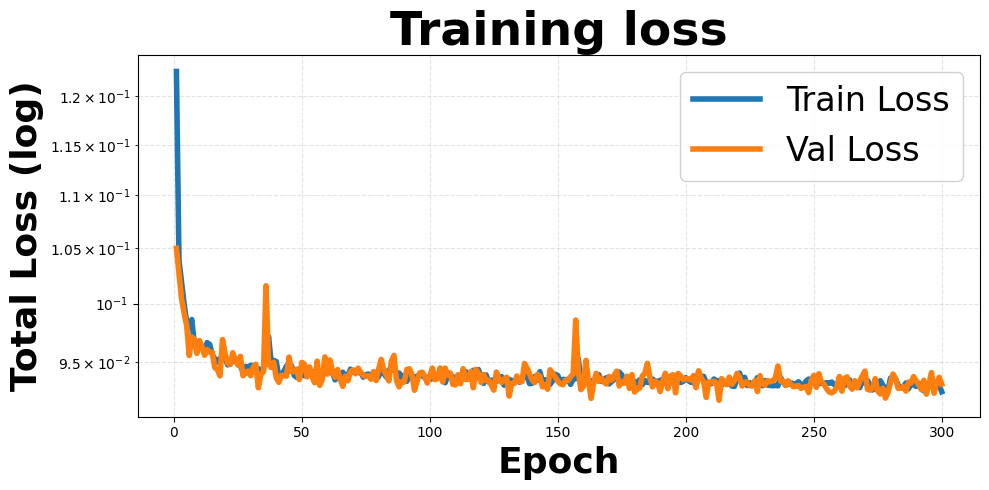

In [30]:
import matplotlib.pyplot as plt
epochs_axis = np.arange(1, len(train_total_losses) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs_axis, train_total_losses, linewidth=4, label="Train Loss")
plt.plot(epochs_axis, val_total_losses, linewidth=4, label="Val Loss")
plt.yscale("log")
plt.xlabel("Epoch", fontsize=26, fontweight="bold")
plt.ylabel("Total Loss (log)", fontsize=26, fontweight="bold")
plt.title("Training loss", fontsize=34, fontweight="bold")
plt.grid(True, which="both", linestyle="--", alpha=0.35)
plt.legend(fontsize=24, framealpha=0.9)
plt.tight_layout()
plt.savefig("diffusion_losses.png")
plt.show()


In [31]:
OUT_DIR = "/data/silvija/diffusion_results"

# Ground-truth raw zR
zr_path = os.path.join(OUT_DIR, "zr_features.npy")            # [N,128]
zr = np.load(zr_path).astype(np.float32)

# Generated zR (your saved output)
zr_gen_path = os.path.join(OUT_DIR, "zr_features_gen.npy")    # [N,128]
zr_gen = np.load(zr_gen_path).astype(np.float32)

# Context used (optional, for cosine checks)
xml_ctx_path = os.path.join(OUT_DIR, "xml_ctx_used.npy")      # [N,128]
xml_ctx_used = np.load(xml_ctx_path).astype(np.float32)

print("zr:", zr.shape, "zr_gen:", zr_gen.shape, "xml_ctx_used:", xml_ctx_used.shape)

zr: (10000, 128) zr_gen: (10000, 128) xml_ctx_used: (10000, 128)


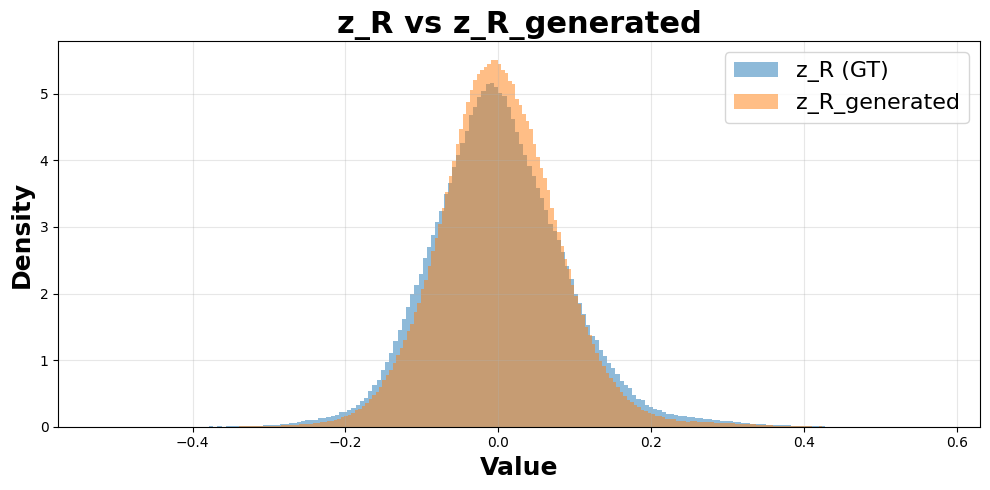

In [32]:
plt.figure(figsize=(10, 5))
plt.hist(zr.reshape(-1), bins=200, alpha=0.5, label="z_R (GT)", density=True)
plt.hist(zr_gen.reshape(-1), bins=200, alpha=0.5, label="z_R_generated", density=True)
plt.title("z_R vs z_R_generated", fontsize=22, fontweight="bold")
plt.xlabel("Value", fontsize=18, fontweight="bold")
plt.ylabel("Density", fontsize=18, fontweight="bold")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=16)
plt.tight_layout()
plt.show()

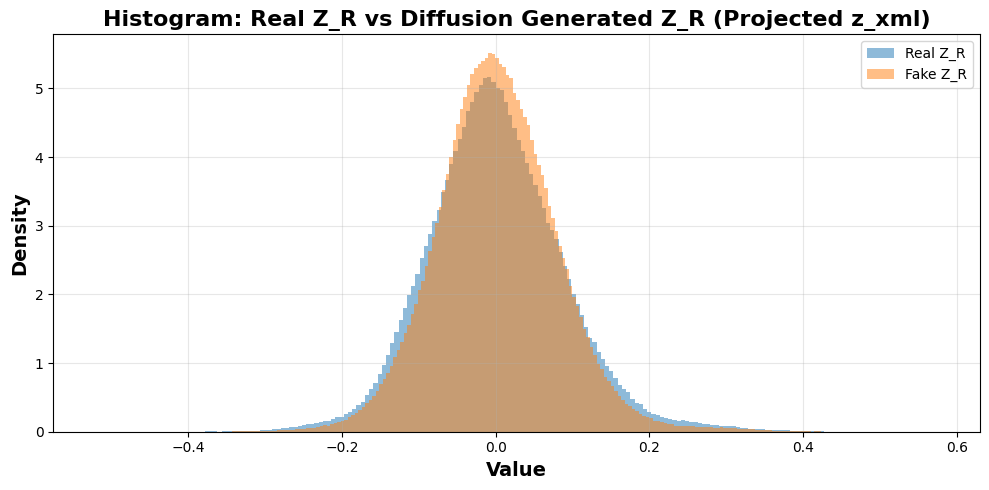

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import os
OUT_DIR = "/data/silvija/diffusion_results"
zr_real = np.load(os.path.join(OUT_DIR, "zr_features.npy"))
zr_generated_proj = np.load(os.path.join(OUT_DIR, "zr_features_gen.npy"))

plt.figure(figsize=(10,5))

plt.hist(zr_real.reshape(-1), bins=200, alpha=0.5,
         label="Real Z_R", density=True)

plt.hist(zr_generated_proj.reshape(-1), bins=200, alpha=0.5,
         label="Fake Z_R", density=True)

plt.title("Histogram: Real Z_R vs Diffusion Generated Z_R (Projected z_xml)",
          fontsize=16, fontweight="bold")

plt.xlabel("Value", fontsize=14, fontweight="bold")
plt.ylabel("Density", fontsize=14, fontweight="bold")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

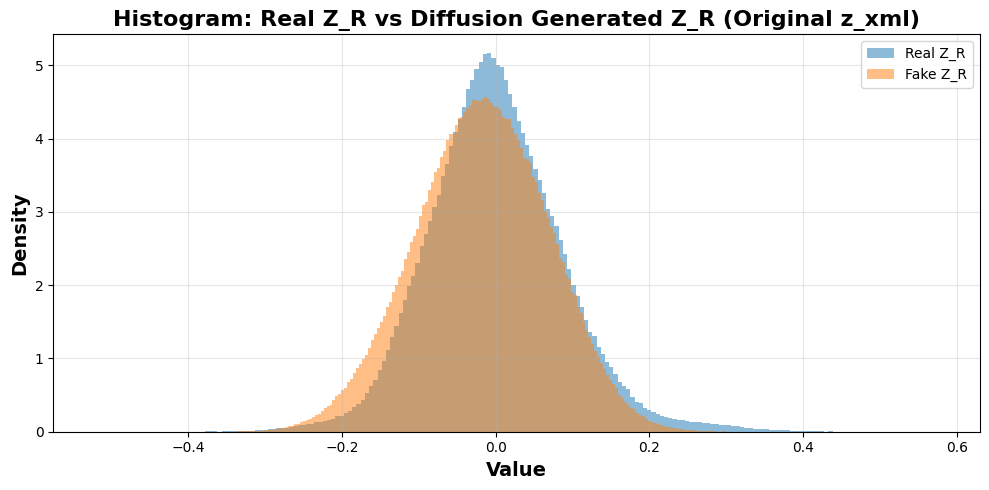

In [34]:
zr_generated_orig = np.load(os.path.join(OUT_DIR, "zr_ctx_gen.npy"))

plt.figure(figsize=(10,5))

plt.hist(zr_real.reshape(-1), bins=200, alpha=0.5,
         label="Real Z_R", density=True)

plt.hist(zr_generated_orig.reshape(-1), bins=200, alpha=0.5,
         label="Fake Z_R", density=True)

plt.title("Histogram: Real Z_R vs Diffusion Generated Z_R (Original z_xml)",
          fontsize=16, fontweight="bold")

plt.xlabel("Value", fontsize=14, fontweight="bold")
plt.ylabel("Density", fontsize=14, fontweight="bold")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Projected z_xml -> generated z_R
Mean cosine similarity: 0.17146753
Std cosine similarity : 0.08748878
Mean cosine distance  : 0.8285325
Std cosine distance   : 0.08748878


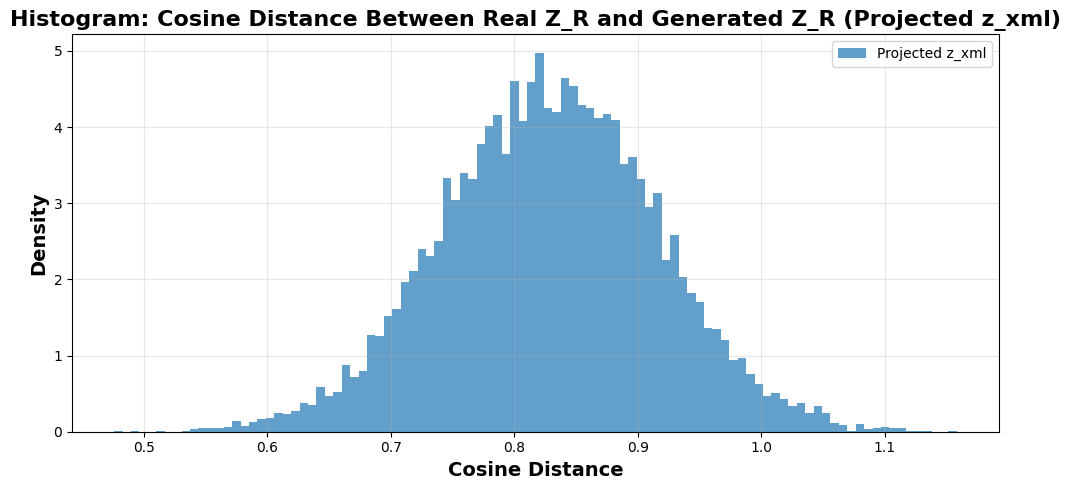

In [35]:
import os
import numpy as np
import matplotlib.pyplot as plt

OUT_DIR = "/data/silvija/diffusion_results"

zr_real = np.load(os.path.join(OUT_DIR, "zr_features.npy")).astype(np.float32)
zr_generated_proj = np.load(os.path.join(OUT_DIR, "zr_features_gen.npy")).astype(np.float32)

def cosine_distance_per_sample(a, b, eps=1e-8):
    a_norm = a / (np.linalg.norm(a, axis=1, keepdims=True) + eps)
    b_norm = b / (np.linalg.norm(b, axis=1, keepdims=True) + eps)
    cos_sim = np.sum(a_norm * b_norm, axis=1)
    cos_dist = 1.0 - cos_sim
    return cos_dist, cos_sim

cos_dist_proj, cos_sim_proj = cosine_distance_per_sample(zr_real, zr_generated_proj)

print("Projected z_xml -> generated z_R")
print("Mean cosine similarity:", cos_sim_proj.mean())
print("Std cosine similarity :", cos_sim_proj.std())
print("Mean cosine distance  :", cos_dist_proj.mean())
print("Std cosine distance   :", cos_dist_proj.std())

plt.figure(figsize=(10,5))
plt.hist(cos_dist_proj, bins=100, alpha=0.7, density=True, label="Projected z_xml")
plt.title("Histogram: Cosine Distance Between Real Z_R and Generated Z_R (Projected z_xml)",
          fontsize=16, fontweight="bold")
plt.xlabel("Cosine Distance", fontsize=14, fontweight="bold")
plt.ylabel("Density", fontsize=14, fontweight="bold")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


Original z_xml -> generated z_R
Mean cosine similarity: 0.010869787
Std cosine similarity : 0.081396915
Mean cosine distance  : 0.9891302
Std cosine distance   : 0.081396915


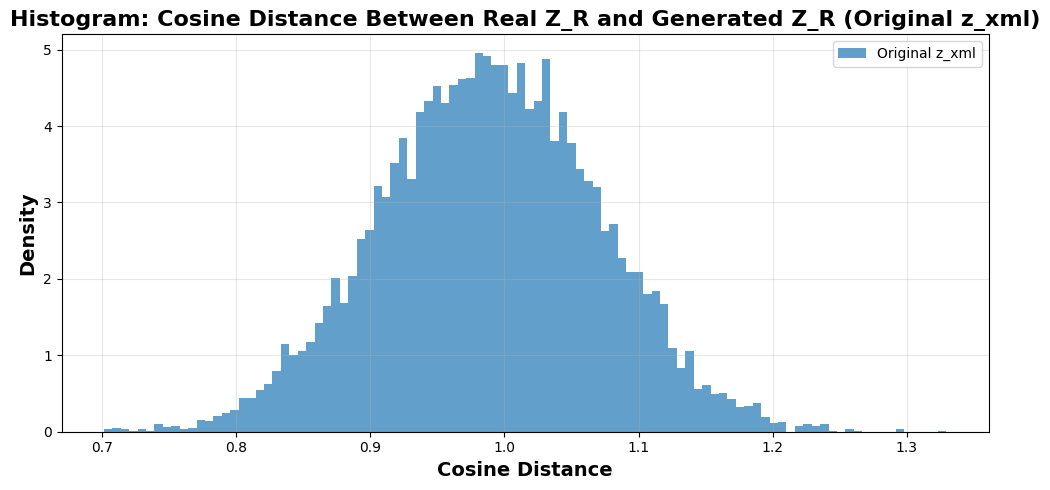

In [36]:
import os
import numpy as np
import matplotlib.pyplot as plt

OUT_DIR = "/data/silvija/diffusion_results"

zr_real = np.load(os.path.join(OUT_DIR, "zr_features.npy")).astype(np.float32)
zr_generated_orig = np.load(os.path.join(OUT_DIR, "zr_ctx_gen.npy")).astype(np.float32)

def cosine_distance_per_sample(a, b, eps=1e-8):
    a_norm = a / (np.linalg.norm(a, axis=1, keepdims=True) + eps)
    b_norm = b / (np.linalg.norm(b, axis=1, keepdims=True) + eps)
    cos_sim = np.sum(a_norm * b_norm, axis=1)
    cos_dist = 1.0 - cos_sim
    return cos_dist, cos_sim

cos_dist_orig, cos_sim_orig = cosine_distance_per_sample(zr_real, zr_generated_orig)

print("Original z_xml -> generated z_R")
print("Mean cosine similarity:", cos_sim_orig.mean())
print("Std cosine similarity :", cos_sim_orig.std())
print("Mean cosine distance  :", cos_dist_orig.mean())
print("Std cosine distance   :", cos_dist_orig.std())

plt.figure(figsize=(10,5))
plt.hist(cos_dist_orig, bins=100, alpha=0.7, density=True, label="Original z_xml")
plt.title("Histogram: Cosine Distance Between Real Z_R and Generated Z_R (Original z_xml)",
          fontsize=16, fontweight="bold")
plt.xlabel("Cosine Distance", fontsize=14, fontweight="bold")
plt.ylabel("Density", fontsize=14, fontweight="bold")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


Projected z_xml
Mean MSE: 0.011661808
Std MSE : 0.0012956418
Min MSE : 0.00687842
Max MSE : 0.017589826


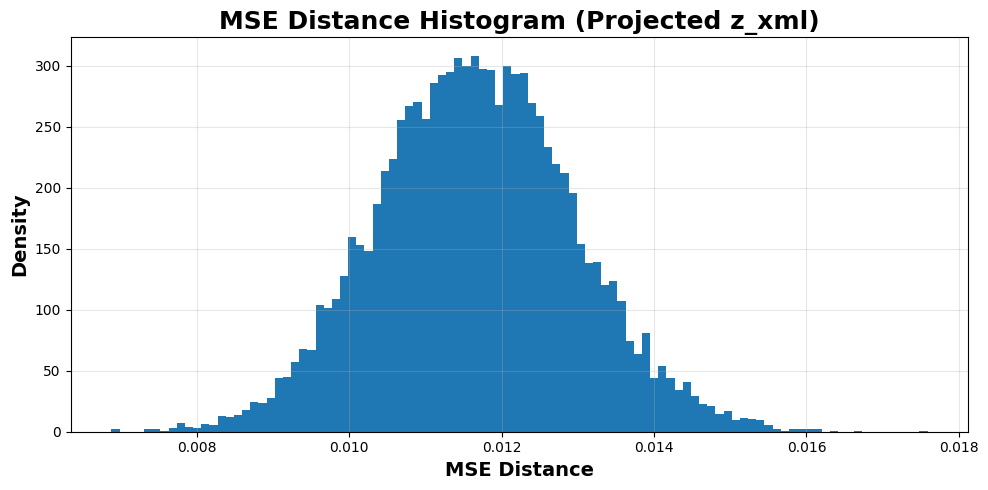

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import os

OUT_DIR = "/data/silvija/diffusion_results"

zr_real = np.load(os.path.join(OUT_DIR, "zr_features.npy"))
zr_generated_proj = np.load(os.path.join(OUT_DIR, "zr_features_gen.npy"))

# compute MSE per sample
mse_proj = np.mean((zr_real - zr_generated_proj) ** 2, axis=1)

print("Projected z_xml")
print("Mean MSE:", mse_proj.mean())
print("Std MSE :", mse_proj.std())
print("Min MSE :", mse_proj.min())
print("Max MSE :", mse_proj.max())

plt.figure(figsize=(10,5))
plt.hist(mse_proj, bins=100, density=True)

plt.title("MSE Distance Histogram (Projected z_xml)",
          fontsize=18, fontweight="bold")
plt.xlabel("MSE Distance", fontsize=14, fontweight="bold")
plt.ylabel("Density", fontsize=14, fontweight="bold")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Original z_xml
Mean MSE: 0.015455159
Std MSE : 0.0012718268
Min MSE : 0.010962122
Max MSE : 0.020773854


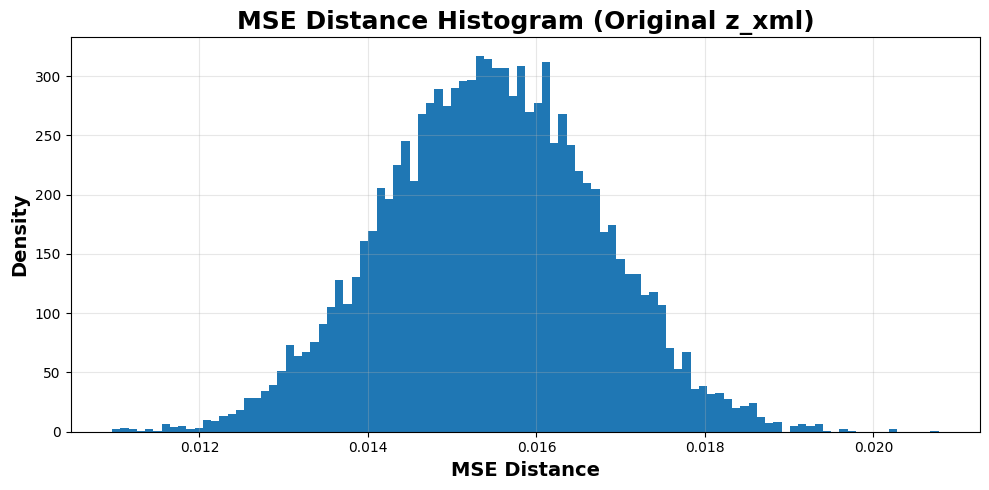

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import os

OUT_DIR = "/data/silvija/diffusion_results"

zr_real = np.load(os.path.join(OUT_DIR, "zr_features.npy"))
zr_generated_orig = np.load(os.path.join(OUT_DIR, "zr_ctx_gen.npy"))

# compute MSE per sample
mse_orig = np.mean((zr_real - zr_generated_orig) ** 2, axis=1)

print("Original z_xml")
print("Mean MSE:", mse_orig.mean())
print("Std MSE :", mse_orig.std())
print("Min MSE :", mse_orig.min())
print("Max MSE :", mse_orig.max())

plt.figure(figsize=(10,5))
plt.hist(mse_orig, bins=100, density=True)

plt.title("MSE Distance Histogram (Original z_xml)",
          fontsize=18, fontweight="bold")
plt.xlabel("MSE Distance", fontsize=14, fontweight="bold")
plt.ylabel("Density", fontsize=14, fontweight="bold")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
